# Hospital Readmissions and Patient Experience in the United States

## Project Overview

This project studies hospital readmissions and patient experience in the United States. It examines whether hospital characteristics and patient survey results are associated with above expected 30 day readmissions.

The analysis uses data from the Centers for Medicare & Medicaid Services (CMS). The readmission data covers 2021–2024, and the patient survey data covers 2022–2023.

## Research Question

Which hospital characteristics and experience of the patient measures are associated with above-expected 30-day readmissions?

## Target Variable

- `high_readmission`: Indicates whether the hospital had an above expected readmission ratio.
- `1`: The excess readmission ratio was above 1.0.
- `0`: The ratio was at or below 1.0.

## Main Features

**Hospital and condition features**

- Medical condition
- Number of discharges
- Hospital ownership
- Emergency services
- EHR interoperability status

**Patient-experience features**

- Nurse communication
- Doctor communication
- Staff responsiveness
- Discharge information
- Care transition
- Hospital recommendation

## 1. Load the Prepared Data

The prepared dataset contains one row for each hospital and medical condition. A hospital can appear more than once because CMS reports readmission results for six different conditions.

### 1.1 Import Libraries

In [7]:
import pandas as pd
import numpy as np

from pathlib import Path
from google.colab import drive

### 1.2 Connect Google Drive

In [9]:
# Connect Google Drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.3 Define the file location

In [10]:
# Project folders
PROJECT_DIR = Path(
    "/content/drive/MyDrive/us_hospital_readmissions_analysis"
)

DATA_DIR = PROJECT_DIR / "data"
DATA_PATH = DATA_DIR / "model_data.csv"

### 1.4 Check that the file exists

In [11]:
# Check that the file exists
print("File found:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"The file was not found here: {DATA_PATH}"
    )

File found: True


### 1.5 Load the prepared dataset

In [12]:
# Load the prepared data

model_data = pd.read_csv(
    DATA_PATH,
    dtype={
        "facility_id": "string",
        "zip_code": "string"
    },
    low_memory=False
)

print("Data loaded successfully.")

Data loaded successfully.


### 1.6 Review the dataset

In [14]:
# Display basic information

print("Data shape:", model_data.shape)

print(
    "Number of hospitals:",
    model_data["facility_id"].nunique()
)

print(
    "Number of conditions:",
    model_data["condition"].nunique()
)

print("\nConditions:")

for condition in sorted(
    model_data["condition"].unique()
):
    print("-", condition)

model_data.head()

Data shape: (11441, 29)
Number of hospitals: 2670
Number of conditions: 6

Conditions:
- Bypass surgery (CABG)
- COPD
- Heart attack (AMI)
- Heart failure
- Hip/knee replacement
- Pneumonia


,facility_id,facility_name,state,city,county,zip_code,condition,measure_name,number_of_discharges,discharge_count_missing,...,definitely_recommend_pct,care_transition_score,completed_surveys,survey_response_rate_pct,excess_readmission_ratio,high_readmission,hrrp_start_date,hrrp_end_date,hcahps_start_date,hcahps_end_date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Hip/knee replacement,READM-30-HIP-KNEE-HRRP,NaN,1,...,74.0,82.0,641.0,17.0,0.9875,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Bypass surgery (CABG),READM-30-CABG-HRRP,137.0,0,...,74.0,82.0,641.0,17.0,0.9531,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Heart attack (AMI),READM-30-AMI-HRRP,273.0,0,...,74.0,82.0,641.0,17.0,0.9370,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,COPD,READM-30-COPD-HRRP,122.0,0,...,74.0,82.0,641.0,17.0,0.9823,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Pneumonia,READM-30-PN-HRRP,507.0,0,...,74.0,82.0,641.0,17.0,0.9871,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023


## 2. Check Data Quality

This section reviews the columns, data types, duplicate rows, missing values, target distribution, and descriptive statistics.

### 2.1 Review the columns and data types

In [15]:
# Create a summary of the columns

column_summary = pd.DataFrame({
    "column": model_data.columns,
    "data_type": model_data.dtypes.astype(str).values
})

print("Number of columns:", len(model_data.columns))

column_summary

Number of columns: 29


,column,data_type
0,facility_id,string
1,facility_name,object
2,state,object
3,city,object
4,county,object
5,zip_code,string
6,condition,object
7,measure_name,object
8,number_of_discharges,float64
9,discharge_count_missing,int64


### 2.2 Check for Duplicate Rows

Each hospital should have only one row for each medical condition.

In [17]:
# Check exact duplicate rows

exact_duplicates = model_data.duplicated().sum()

# Check duplicate hospital-condition combinations

hospital_condition_duplicates = model_data.duplicated(
    subset=[
        "facility_id",
        "condition"
    ]
).sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

print(
    "Duplicate hospital condition rows:",
    hospital_condition_duplicates
)

Exact duplicate rows: 0
Duplicate hospital condition rows: 0


### 2.3 Check Missing Values

Missing values can affect the analysis and the model. This table shows the number and percentage of missing values in each column.

In [18]:
# Create a missing-value summary

missing_summary = pd.DataFrame({
    "missing_values": model_data.isna().sum(),
    "missing_pct": (
        model_data.isna().mean() * 100
    ).round(1)
})

# Show only columns with missing values

missing_summary = missing_summary[
    missing_summary["missing_values"] > 0
]

missing_summary

,missing_values,missing_pct
number_of_discharges,3457,30.2


- Approximately 30.2% of its values are missing.

### 2.4 Review the Target Distribution

The target variable is `high_readmission`.

- `0` means the readmission ratio was at or below the expected level.
- `1` means the readmission ratio was above the expected level.

In [19]:
# Create a target summary

target_summary = (
    model_data["high_readmission"]
    .value_counts()
    .sort_index()
    .rename_axis("high_readmission")
    .reset_index(name="count")
)

# Add readable labels

target_summary["readmission_group"] = (
    target_summary["high_readmission"]
    .map({
        0: "At or below expected",
        1: "Above expected"
    })
)

# Calculate percentages

target_summary["percentage"] = (
    target_summary["count"]
    / target_summary["count"].sum()
    * 100
).round(1)

target_summary[
    [
        "high_readmission",
        "readmission_group",
        "count",
        "percentage"
    ]
]

,high_readmission,readmission_group,count,percentage
0,0,At or below expected,5919,51.7
1,1,Above expected,5522,48.3


### 2.5 Review Descriptive Statistics

The following table summarizes the main numeric variables.

In [20]:
# Select the main numeric variables

analysis_columns = [
    "number_of_discharges",
    "nurse_communication_pct",
    "doctor_communication_pct",
    "staff_responsiveness_pct",
    "discharge_information_pct",
    "definitely_recommend_pct",
    "care_transition_score",
    "excess_readmission_ratio"
]

# Display descriptive statistics

model_data[
    analysis_columns
].describe().round(2)

,number_of_discharges,nurse_communication_pct,doctor_communication_pct,staff_responsiveness_pct,discharge_information_pct,definitely_recommend_pct,care_transition_score,excess_readmission_ratio
count,7984.00,11441.00,11441.00,11441.00,11441.00,11441.00,11441.00,11441.00
mean,292.02,76.32,76.68,59.34,85.22,66.65,79.85,1.00
std,270.85,4.81,4.55,7.37,3.69,9.33,2.76,0.08
min,27.00,56.00,56.00,31.00,64.00,29.00,67.00,0.47
25%,123.00,73.00,74.00,55.00,83.00,61.00,78.00,0.96
50%,204.00,77.00,77.00,59.00,86.00,67.00,80.00,1.00
75%,366.00,79.00,80.00,64.00,88.00,73.00,82.00,1.04
max,3672.00,99.00,99.00,100.00,100.00,97.00,97.00,1.63


### Data Quality Summary

- The dataset contained no duplicate hospital condition rows. Most variables had no missing values. The number of discharges was missing for about 30% of the rows.

- The missing discharge values will not be filled during this section. They will be handled inside the model pipeline using only the training data. This helps prevent data leakage.

- The target was almost balanced. About 48.3% of the rows had above expected readmissions, while 51.7% were at or below the expected level.

## 3. Explore the Readmission Target

This section explores the target variable and the excess readmission ratio. It also compares above-expected readmissions across the six medical conditions.

### 3.1 Set the Chart Style

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Soft pink colors

LIGHT_PINK = "#F7D6DF"
SOFT_PINK = "#E6A0B2"
DARK_PINK = "#B85C74"
DEEP_ROSE = "#8F4058"

# Chart style

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

### 3.2 Target Distribution

This chart compares hospital condition rows with above expected readmissions to rows that were at or below the expected level.

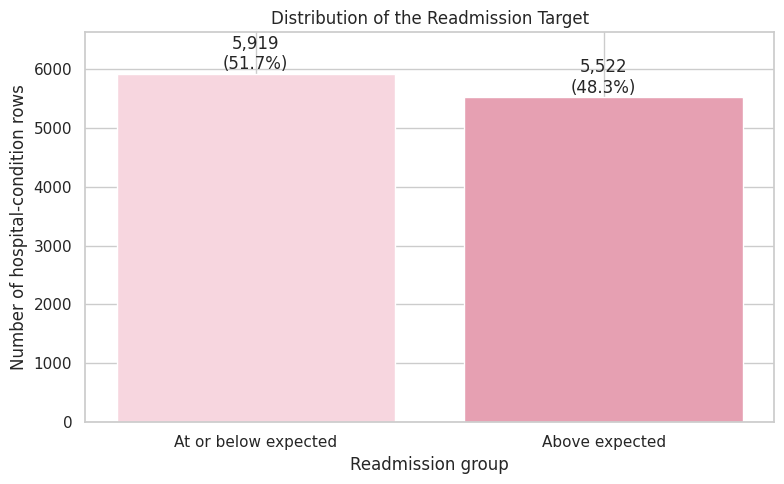

In [23]:
# Create a target summary for the chart

target_chart = (
    model_data["high_readmission"]
    .value_counts()
    .sort_index()
    .rename_axis("high_readmission")
    .reset_index(name="count")
)

target_chart["readmission_group"] = (
    target_chart["high_readmission"]
    .map({
        0: "At or below expected",
        1: "Above expected"
    })
)

target_chart["percentage"] = (
    target_chart["count"]
    / target_chart["count"].sum()
    * 100
).round(1)

# Create the chart

plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_chart["readmission_group"],
    target_chart["count"],
    color=[LIGHT_PINK, SOFT_PINK],
    edgecolor="white"
)

plt.title(
    "Distribution of the Readmission Target"
)

plt.xlabel("Readmission group")
plt.ylabel("Number of hospital-condition rows")

# Add count and percentage labels

for bar, (_, row) in zip(
    bars,
    target_chart.iterrows()
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 70,
        f'{row["count"]:,}\n({row["percentage"]:.1f}%)',
        ha="center"
    )

plt.ylim(
    0,
    target_chart["count"].max() + 700
)

plt.tight_layout()
plt.show()

- The two target groups were similar in size. About 48.3% of the rows had above expected readmissions, and 51.7% were at or below the expected level.

- This balance is helpful because the model will have enough examples from both groups.

### 3.3 Distribution of the Excess Readmission Ratio

An excess readmission ratio above 1.0 means that readmissions were higher than expected. The dashed line shows this cutoff.

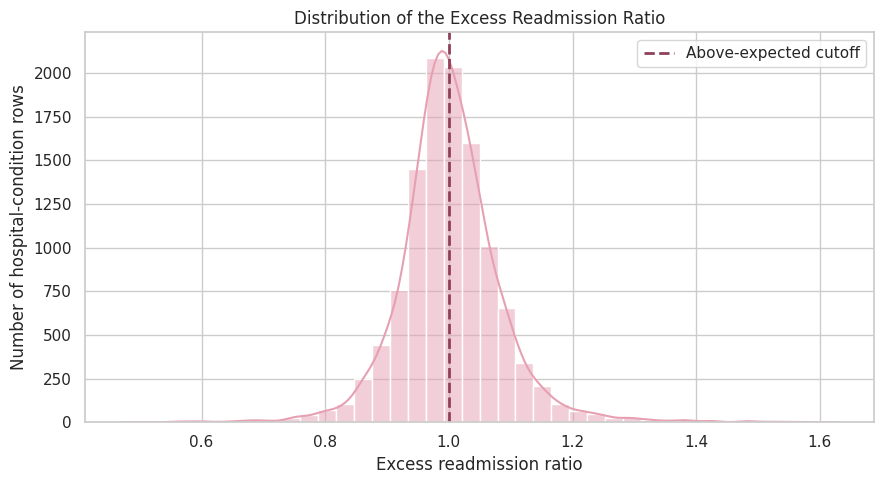

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=model_data,
    x="excess_readmission_ratio",
    bins=40,
    kde=True,
    color=SOFT_PINK,
    edgecolor="white"
)

# Add the target cutoff

plt.axvline(
    1.0,
    color=DEEP_ROSE,
    linestyle="--",
    linewidth=2,
    label="Above-expected cutoff"
)

plt.title(
    "Distribution of the Excess Readmission Ratio"
)

plt.xlabel("Excess readmission ratio")
plt.ylabel("Number of hospital-condition rows")

plt.legend()

plt.tight_layout()
plt.show()

- Most excess readmission ratios were close to 1.0. Values on the right side of the dashed line represent above expected readmissions. Values on the left side were at or below the expected level.

### 3.4 Above-Expected Readmissions by Medical Condition

This chart shows the percentage of above expected readmission rows for each medical condition.

In [25]:
# Calculate the percentage for each condition

condition_summary = (
    model_data
    .groupby(
        "condition",
        as_index=False
    )
    .agg(
        hospital_condition_rows=(
            "high_readmission",
            "size"
        ),
        high_readmission_pct=(
            "high_readmission",
            lambda values: values.mean() * 100
        )
    )
    .sort_values(
        "high_readmission_pct",
        ascending=True
    )
)

condition_summary[
    "high_readmission_pct"
] = condition_summary[
    "high_readmission_pct"
].round(1)

condition_summary

,condition,hospital_condition_rows,high_readmission_pct
5,Pneumonia,2573,47.3
1,COPD,2287,47.3
4,Hip/knee replacement,1428,47.9
3,Heart failure,2543,48.8
2,Heart attack (AMI),1732,49.7
0,Bypass surgery (CABG),878,49.9


### 3.5 Create the Condition Comparison Chart

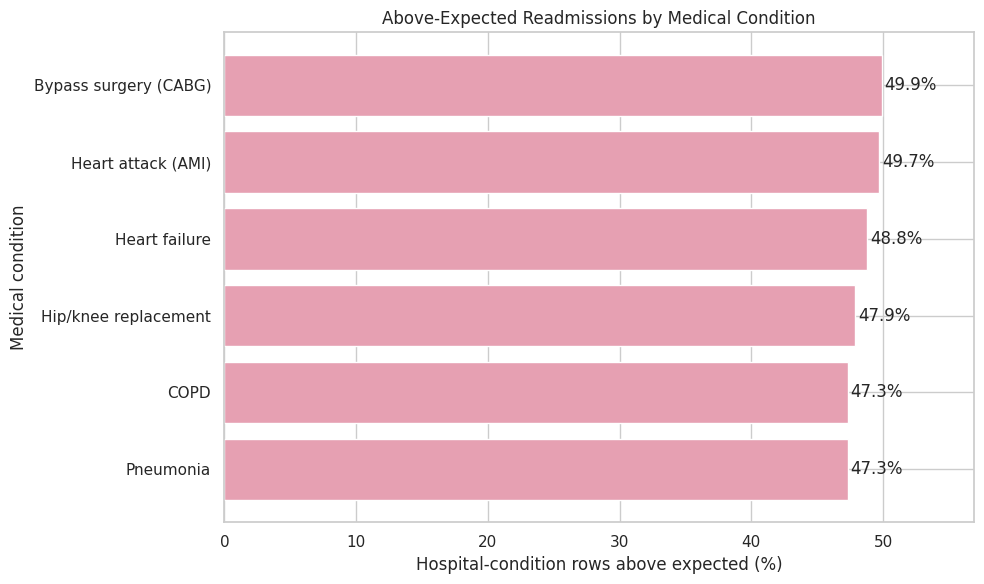

In [26]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    condition_summary["condition"],
    condition_summary["high_readmission_pct"],
    color=SOFT_PINK,
    edgecolor="white"
)

plt.title(
    "Above-Expected Readmissions by Medical Condition"
)

plt.xlabel(
    "Hospital-condition rows above expected (%)"
)

plt.ylabel("Medical condition")

# Add percentage labels

for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(
    0,
    condition_summary[
        "high_readmission_pct"
    ].max() + 7
)

plt.tight_layout()
plt.show()

- Bypass surgery and heart attack had the highest percentages of above expected readmissions. COPD and pneumonia had the lowest percentages.

- However, the differences between the conditions were small. These results describe the dataset, but they do not explain why the differences occurred.

## 4. Explore Hospital Characteristics and Patient Experience

This section compares above expected readmissions across hospital ownership groups and emergency service status. It also compares average patient experience scores between the two target groups.

### 4.1 Above Expected Readmissions by Ownership Group

This table shows the number of hospitals and the percentage of above expected hospital condition rows in each ownership group.

In [27]:
# Create an ownership summary

ownership_summary = (
    model_data
    .groupby(
        "ownership_group",
        as_index=False
    )
    .agg(
        hospital_condition_rows=(
            "high_readmission",
            "size"
        ),
        hospitals=(
            "facility_id",
            "nunique"
        ),
        high_readmission_pct=(
            "high_readmission",
            lambda values: values.mean() * 100
        )
    )
)

ownership_summary[
    "high_readmission_pct"
] = ownership_summary[
    "high_readmission_pct"
].round(1)

ownership_summary = ownership_summary.sort_values(
    "high_readmission_pct",
    ascending=True
)

ownership_summary

,ownership_group,hospital_condition_rows,hospitals,high_readmission_pct
4,Tribal,11,4,36.4
2,Physician-owned,75,44,41.3
1,Nonprofit,7913,1769,46.3
0,Government,1383,344,50.3
3,Proprietary,2059,509,54.7


### 4.2 Create the Ownership Comparison Chart

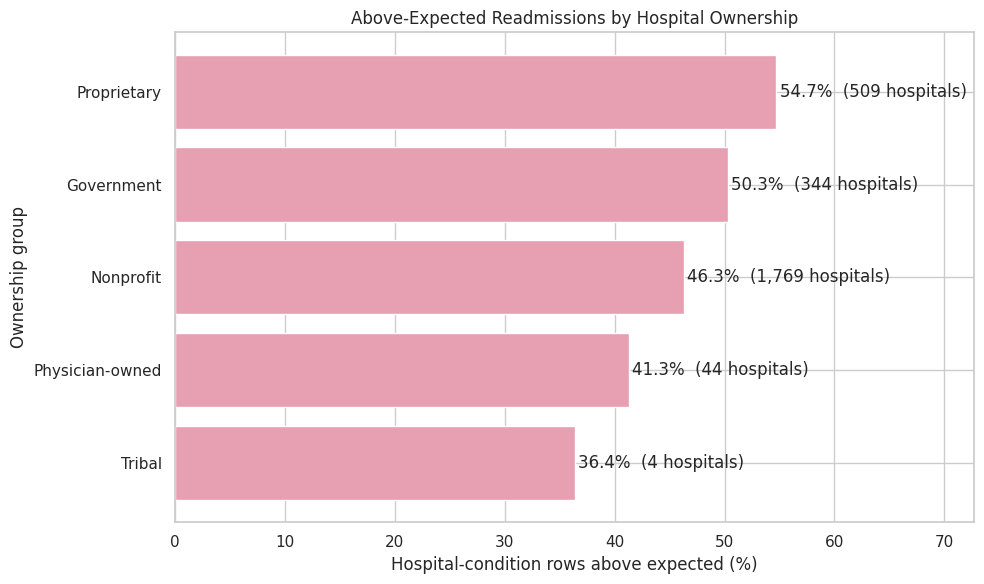

In [28]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    ownership_summary["ownership_group"],
    ownership_summary["high_readmission_pct"],
    color=SOFT_PINK,
    edgecolor="white"
)

plt.title(
    "Above-Expected Readmissions by Hospital Ownership"
)

plt.xlabel(
    "Hospital-condition rows above expected (%)"
)

plt.ylabel("Ownership group")

# Add percentages and hospital counts

for bar, (_, row) in zip(
    bars,
    ownership_summary.iterrows()
):
    value = bar.get_width()

    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%  ({row["hospitals"]:,} hospitals)',
        va="center"
    )

plt.xlim(
    0,
    ownership_summary[
        "high_readmission_pct"
    ].max() + 18
)

plt.tight_layout()
plt.show()

- Proprietary hospitals had the highest percentage of above-expected readmissions in this dataset. Government and nonprofit hospitals had lower percentages.

- The physician-owned and Tribal groups included fewer hospitals. Their percentages should be read carefully because small groups can change more easily.

### 4.3 Compare Hospitals by Emergency Service Status

In [29]:
# Compare hospitals with and without emergency services

emergency_summary = (
    model_data
    .groupby(
        "emergency_services",
        as_index=False
    )
    .agg(
        hospital_condition_rows=(
            "high_readmission",
            "size"
        ),
        hospitals=(
            "facility_id",
            "nunique"
        ),
        high_readmission_pct=(
            "high_readmission",
            lambda values: values.mean() * 100
        )
    )
)

emergency_summary[
    "high_readmission_pct"
] = emergency_summary[
    "high_readmission_pct"
].round(1)

emergency_summary

,emergency_services,hospital_condition_rows,hospitals,high_readmission_pct
0,No,473,156,51.4
1,Yes,10968,2514,48.1


Hospitals without emergency services had a slightly higher percentage of above expected readmissions. However, this group was much smaller than the group with emergency services. The difference should be interpreted carefully.

### 4.4 Compare Patient Experience by Readmission Group

This comparison shows the average patient experience scores for the two target groups.

In [30]:
# Select patient-experience variables

experience_columns = [
    "nurse_communication_pct",
    "doctor_communication_pct",
    "staff_responsiveness_pct",
    "discharge_information_pct",
    "definitely_recommend_pct",
    "care_transition_score"
]

# Readable names for the chart

experience_labels = {
    "nurse_communication_pct":
        "Nurse communication",
    "doctor_communication_pct":
        "Doctor communication",
    "staff_responsiveness_pct":
        "Staff responsiveness",
    "discharge_information_pct":
        "Discharge information",
    "definitely_recommend_pct":
        "Definitely recommend",
    "care_transition_score":
        "Care transition"
}

# Calculate averages

experience_summary = (
    model_data
    .groupby("high_readmission")[
        experience_columns
    ]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

experience_summary = experience_summary.rename(
    columns={
        0: "At or below expected",
        1: "Above expected"
    }
)

experience_summary["measure"] = (
    experience_summary["variable"]
    .map(experience_labels)
)

experience_summary[
    [
        "measure",
        "At or below expected",
        "Above expected"
    ]
].round(1)

high_readmission,measure,At or below expected,Above expected
0,Nurse communication,76.9,75.7
1,Doctor communication,77.3,76.1
2,Staff responsiveness,60.0,58.6
3,Discharge information,85.8,84.6
4,Definitely recommend,67.8,65.4
5,Care transition,80.2,79.4


### 4.5 Prepare the Patient Experience Chart

In [31]:
# Reshape the summary for the chart

experience_chart = experience_summary.melt(
    id_vars=[
        "variable",
        "measure"
    ],
    value_vars=[
        "At or below expected",
        "Above expected"
    ],
    var_name="readmission_group",
    value_name="average_score"
)

experience_chart.head()

,variable,measure,readmission_group,average_score
0,nurse_communication_pct,Nurse communication,At or below expected,76.875148
1,doctor_communication_pct,Doctor communication,At or below expected,77.258996
2,staff_responsiveness_pct,Staff responsiveness,At or below expected,60.025849
3,discharge_information_pct,Discharge information,At or below expected,85.787295
4,definitely_recommend_pct,Definitely recommend,At or below expected,67.781382


### 4.6 Create the Patient Experience Comparison Chart

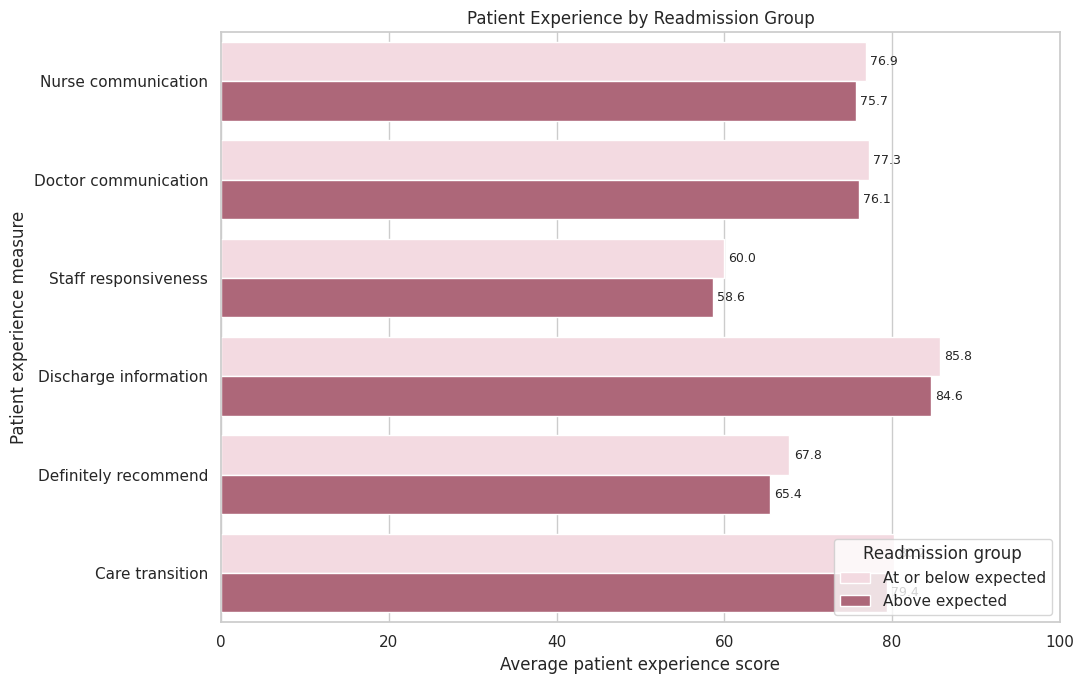

In [33]:
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=experience_chart,
    x="average_score",
    y="measure",
    hue="readmission_group",
    palette={
        "At or below expected": LIGHT_PINK,
        "Above expected": DARK_PINK
    }
)

plt.title(
    "Patient Experience by Readmission Group"
)

plt.xlabel("Average patient experience score")
plt.ylabel("Patient experience measure")

plt.xlim(0, 100)

plt.legend(
    title="Readmission group",
    loc="lower right"
)

# Add values to the bars

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

- Hospitals at or below the expected readmission level had slightly higher averages for all six patient-experience measures.

- The largest difference was in the percentage of patients who would definitely recommend the hospital. However, the differences were small. These results show a relationship, but they do not prove that better patient experience directly reduces readmissions.

## 5. Correlation Analysis

This section examines the relationships between the numeric predictors and the readmission target.

The `excess_readmission_ratio` is not included because it was used to create the target. Including it would cause data leakage.

### 5.1 Select the Numeric Variables

In [34]:
# Select numeric predictors and the target

correlation_columns = [
    "number_of_discharges",
    "nurse_communication_pct",
    "doctor_communication_pct",
    "staff_responsiveness_pct",
    "discharge_information_pct",
    "definitely_recommend_pct",
    "care_transition_score",
    "high_readmission"
]

# Create readable labels

correlation_labels = {
    "number_of_discharges":
        "Number of discharges",
    "nurse_communication_pct":
        "Nurse communication",
    "doctor_communication_pct":
        "Doctor communication",
    "staff_responsiveness_pct":
        "Staff responsiveness",
    "discharge_information_pct":
        "Discharge information",
    "definitely_recommend_pct":
        "Definitely recommend",
    "care_transition_score":
        "Care transition",
    "high_readmission":
        "Above-expected target"
}

### 5.2 Calculate the Correlation Matrix

Correlation values range from -1 to 1.

- A positive value means that two variables tend to increase together.
- A negative value means that one variable tends to decrease when the other increases.
- A value close to zero means that the relationship is weak.

In [35]:
# Rename the columns and calculate correlations

correlation_data = (
    model_data[correlation_columns]
    .rename(columns=correlation_labels)
)

correlation_matrix = (
    correlation_data
    .corr()
    .round(2)
)

correlation_matrix

,Number of discharges,Nurse communication,Doctor communication,Staff responsiveness,Discharge information,Definitely recommend,Care transition,Above-expected target
Number of discharges,1.00,0.04,-0.00,-0.06,0.06,0.16,0.09,-0.11
Nurse communication,0.04,1.00,0.80,0.81,0.72,0.70,0.85,-0.12
Doctor communication,-0.00,0.80,1.00,0.68,0.62,0.65,0.79,-0.13
Staff responsiveness,-0.06,0.81,0.68,1.00,0.59,0.55,0.70,-0.10
Discharge information,0.06,0.72,0.62,0.59,1.00,0.60,0.80,-0.16
Definitely recommend,0.16,0.70,0.65,0.55,0.60,1.00,0.82,-0.13
Care transition,0.09,0.85,0.79,0.70,0.80,0.82,1.00,-0.15
Above-expected target,-0.11,-0.12,-0.13,-0.10,-0.16,-0.13,-0.15,1.00


### 5.3 Create the Correlation Heatmap

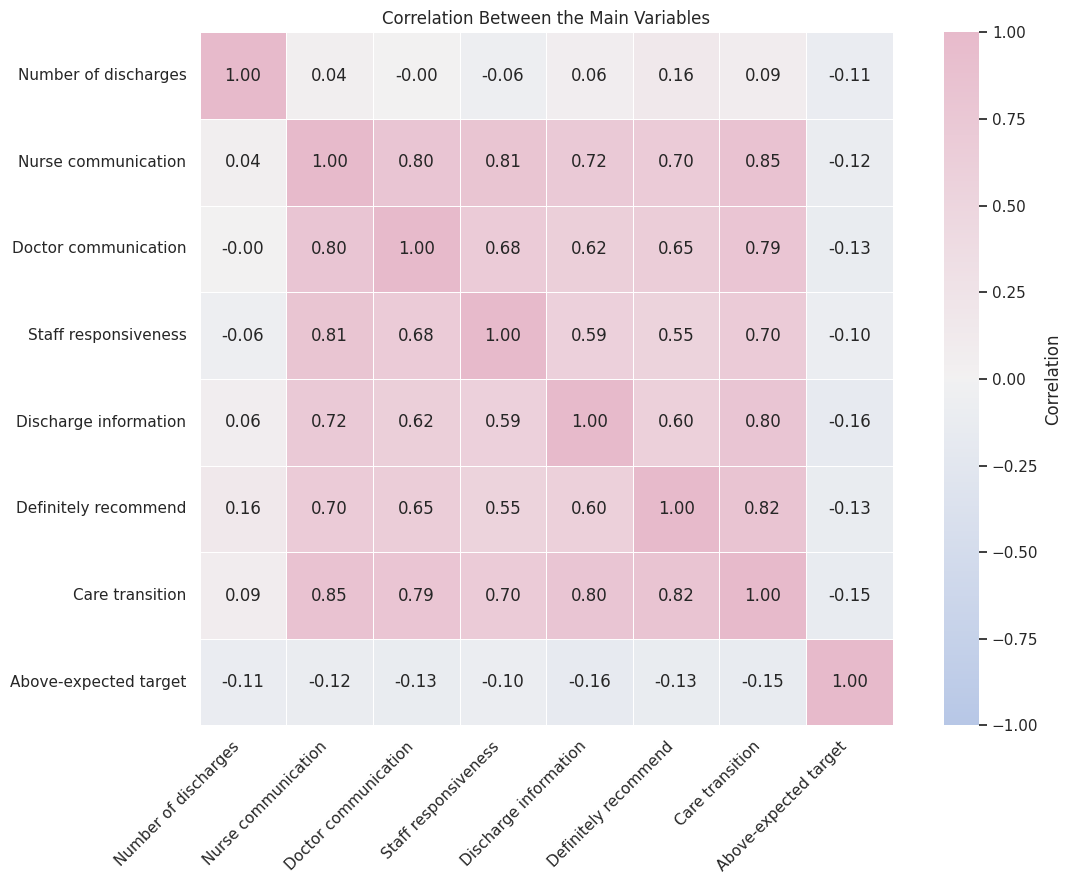

In [36]:
# Create a soft pink and lavender color map

soft_correlation_colors = (
    sns.diverging_palette(
        250,
        345,
        s=55,
        l=80,
        center="light",
        as_cmap=True
    )
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=soft_correlation_colors,
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.7,
    square=True,
    cbar_kws={
        "label": "Correlation"
    }
)

plt.title(
    "Correlation Between the Main Variables"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

- The patient experience measures had strong positive correlations with each other. For example, hospitals with higher nurse communication scores also tended to have higher care transition and staff responsiveness scores.

- This makes sense because these variables describe related parts of the patient experience.

### 5.4 Review Correlations With the Target

This table shows how each numeric predictor was related to the above-expected readmission target.

In [37]:
# Select correlations with the target

target_correlations = (
    correlation_matrix[
        "Above-expected target"
    ]
    .drop("Above-expected target")
    .sort_values()
    .reset_index()
)

target_correlations.columns = [
    "predictor",
    "correlation"
]

target_correlations

,predictor,correlation
0,Discharge information,-0.16
1,Care transition,-0.15
2,Doctor communication,-0.13
3,Definitely recommend,-0.13
4,Nurse communication,-0.12
5,Number of discharges,-0.11
6,Staff responsiveness,-0.10


### 5.5 Create the Target Correlation Chart

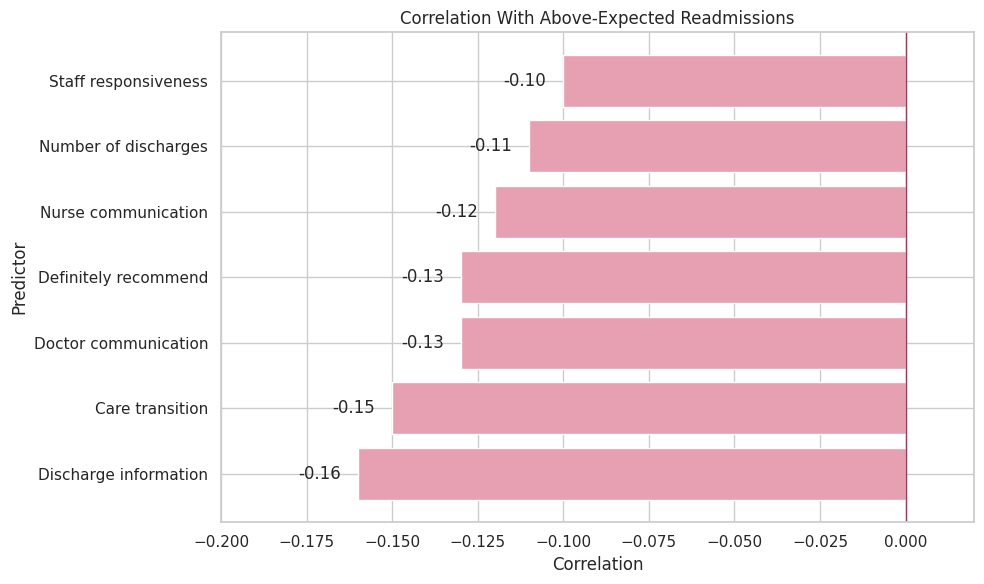

In [38]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    target_correlations["predictor"],
    target_correlations["correlation"],
    color=SOFT_PINK,
    edgecolor="white"
)

# Add a line at zero

plt.axvline(
    0,
    color=DEEP_ROSE,
    linewidth=1
)

plt.title(
    "Correlation With Above-Expected Readmissions"
)

plt.xlabel("Correlation")
plt.ylabel("Predictor")

# Add values to the bars

for bar in bars:
    value = bar.get_width()

    plt.text(
        value - 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        ha="right",
        va="center"
    )

plt.xlim(-0.20, 0.02)

plt.tight_layout()
plt.show()

- All numeric predictors had weak negative correlations with above expected readmissions. Discharge information had the strongest correlation at approximately -0.16, followed by care transition at approximately -0.15.

- This means that higher patient experience scores were connected with a slightly lower chance of above expected readmissions. However, the relationships were weak and do not prove that better patient experience directly reduces readmissions.

## 6. Prepare the Data for Classification

This section selects the model features and separates the data into training and testing groups.

The same hospital can appear in several rows because CMS reports different medical conditions. For this reason, the data will be split by hospital ID. A hospital will not appear in both training and testing data.

### 6.1 Import the Modeling Tools

In [39]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

### 6.2 Select the Model Features

The model uses hospital characteristics, medical condition, discharge volume, and patient experience measures.

Hospital names, hospital IDs, location fields, and the excess readmission ratio are not used as predictors.

In [40]:
# Numeric features

numeric_features = [
    "number_of_discharges",
    "nurse_communication_pct",
    "doctor_communication_pct",
    "staff_responsiveness_pct",
    "discharge_information_pct",
    "definitely_recommend_pct",
    "care_transition_score"
]

# Categorical features

categorical_features = [
    "condition",
    "ownership_group",
    "emergency_services",
    "promoting_interoperability"
]

# Combine the feature lists

model_features = (
    numeric_features
    + categorical_features
)

print("Numeric features:")

for feature in numeric_features:
    print("-", feature)

print("\nCategorical features:")

for feature in categorical_features:
    print("-", feature)

Numeric features:
- number_of_discharges
- nurse_communication_pct
- doctor_communication_pct
- staff_responsiveness_pct
- discharge_information_pct
- definitely_recommend_pct
- care_transition_score

Categorical features:
- condition
- ownership_group
- emergency_services
- promoting_interoperability


### 6.3 Define the Features, Target, and Hospital Groups

In [41]:
# Features

X = model_data[model_features].copy()

# Target

y = model_data[
    "high_readmission"
].copy()

# Hospital groups

groups = model_data[
    "facility_id"
].copy()

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)
print("Hospital groups:", groups.nunique())

Feature data shape: (11441, 11)
Target data shape: (11441,)
Hospital groups: 2670


### 6.4 Create the Training and Testing Data

Approximately 80% of the hospitals will be used for training and 20% will be used for testing.

In [42]:
# Create a group-based split

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    group_split.split(
        X,
        y,
        groups=groups
    )
)

# Create the training data

X_train = X.iloc[
    train_index
].copy()

y_train = y.iloc[
    train_index
].copy()

groups_train = groups.iloc[
    train_index
].copy()

# Create the testing data

X_test = X.iloc[
    test_index
].copy()

y_test = y.iloc[
    test_index
].copy()

groups_test = groups.iloc[
    test_index
].copy()

### 6.5 Check the Training and Testing Split

In [43]:
# Check for hospitals in both groups

hospital_overlap = set(
    groups_train
).intersection(
    set(groups_test)
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print(
    "Training hospitals:",
    groups_train.nunique()
)

print(
    "Testing hospitals:",
    groups_test.nunique()
)

print(
    "Hospitals in both groups:",
    len(hospital_overlap)
)

print(
    "\nTraining target percentage:",
    round(y_train.mean() * 100, 1)
)

print(
    "Testing target percentage:",
    round(y_test.mean() * 100, 1)
)

Training rows: 9222
Testing rows: 2219
Training hospitals: 2136
Testing hospitals: 534
Hospitals in both groups: 0

Training target percentage: 48.7
Testing target percentage: 46.5


### 6.6 Prepare the Numeric Features

The number of discharges contains missing values. The pipeline will replace them with the median from the training data.

The pipeline will also create a missing-value indicator and standardize the numeric features.

In [44]:
# Numeric preparation steps

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### 6.7 Prepare the Categorical Features

Missing categories will be replaced with the most common training value. The categories will then be converted into numeric columns.

In [45]:
# Categorical preparation steps

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### 6.8 Create the Full Preprocessing Pipeline

In [46]:
# Combine numeric and categorical preparation

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


- The data was divided by hospital instead of by individual row. This prevents the same hospital from appearing in both the training and testing groups.

- There were 2,136 hospitals in the training group and 534 hospitals in the testing group. No hospitals appeared in both groups.

- The preprocessing steps will be fitted only with the training data. Missing discharge values will be filled with the training median, numeric features will be standardized, and categorical features will be converted into numeric columns.

## 7. Compare Classification Models

This section compares four classification models using grouped cross validation.

The hospital groups are kept together during cross validation. This means that the same hospital will not appear in both the training and validation groups.

The testing data will not be used in this section.

### 7.1 Import the Classification and Evaluation Tools

In [47]:
from sklearn.base import clone

from sklearn.model_selection import (
    GroupKFold,
    cross_validate
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

### 7.2 Define the Classification Models

Four models will be compared:

- Majority Baseline
- Logistic Regression
- Random Forest
- Gradient Boosting

The baseline always predicts the most common target group. It provides a simple result that the other models should improve.

In [48]:
# Define the models

models = {
    "Majority Baseline":
        DummyClassifier(
            strategy="prior",
            random_state=42
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            random_state=42
        )
}

print("Models:")

for model_name in models:
    print("-", model_name)

Models:
- Majority Baseline
- Logistic Regression
- Random Forest
- Gradient Boosting


### 7.3 Define the Evaluation Metrics

The models will be compared with five metrics:

- **Accuracy:** The percentage of all correct predictions.
- **Precision:** How often an above expected prediction was correct.
- **Recall:** How many above expected rows the model found.
- **F1 score:** A balance between precision and recall.
- **ROC-AUC:** How well the model separates the two target groups.

In [49]:
 # Define the evaluation metrics

scoring = {
    "Accuracy": "accuracy",

    "Precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "Recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "F1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "ROC_AUC": "roc_auc"
}

### 7.4 Create Grouped Cross Validation

The training hospitals will be divided into five groups. Each group will be used once for validation.

In [50]:
# Create five hospital-based folds

group_cv = GroupKFold(
    n_splits=5
)

print(
    "Cross-validation folds:",
    group_cv.get_n_splits()
)

Cross-validation folds: 5


### 7.5 Evaluate the Models

This cell may take a few minutes because every model is trained five times.

In [51]:
# Store the cross-validation results

cv_results = []

for model_name, classifier in models.items():

    print("Evaluating:", model_name)

    # Create a complete model pipeline

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    # Evaluate the model

    scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=group_cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )

    # Save the average results

    cv_results.append({
        "Model": model_name,
        "Accuracy": scores[
            "test_Accuracy"
        ].mean(),
        "Precision": scores[
            "test_Precision"
        ].mean(),
        "Recall": scores[
            "test_Recall"
        ].mean(),
        "F1": scores[
            "test_F1"
        ].mean(),
        "ROC_AUC": scores[
            "test_ROC_AUC"
        ].mean()
    })

print("Cross-validation complete.")

Evaluating: Majority Baseline
Evaluating: Logistic Regression
Evaluating: Random Forest
Evaluating: Gradient Boosting
Cross-validation complete.


### 7.6 Review the Cross-Validation Results

In [52]:
# Create the results table

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

cv_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.613,0.626,0.515,0.564,0.666
1,Random Forest,0.612,0.608,0.573,0.590,0.665
2,Logistic Regression,0.600,0.584,0.620,0.602,0.644
3,Majority Baseline,0.513,0.000,0.000,0.000,0.500


### 7.7 Prepare the Model Comparison Chart

The chart compares the F1 and ROC-AUC scores. Higher scores are better.

In [53]:
# Reshape the results for the chart

cv_chart = cv_results_df.melt(
    id_vars="Model",
    value_vars=[
        "F1",
        "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

cv_chart["Metric"] = (
    cv_chart["Metric"]
    .replace({
        "ROC_AUC": "ROC-AUC"
    })
)

cv_chart

,Model,Metric,Score
0,Gradient Boosting,F1,0.564120
1,Random Forest,F1,0.589989
2,Logistic Regression,F1,0.601617
3,Majority Baseline,F1,0.000000
4,Gradient Boosting,ROC-AUC,0.665932
5,Random Forest,ROC-AUC,0.664815
6,Logistic Regression,ROC-AUC,0.643684
7,Majority Baseline,ROC-AUC,0.500000


### 7.8 Create the Model Comparison Chart

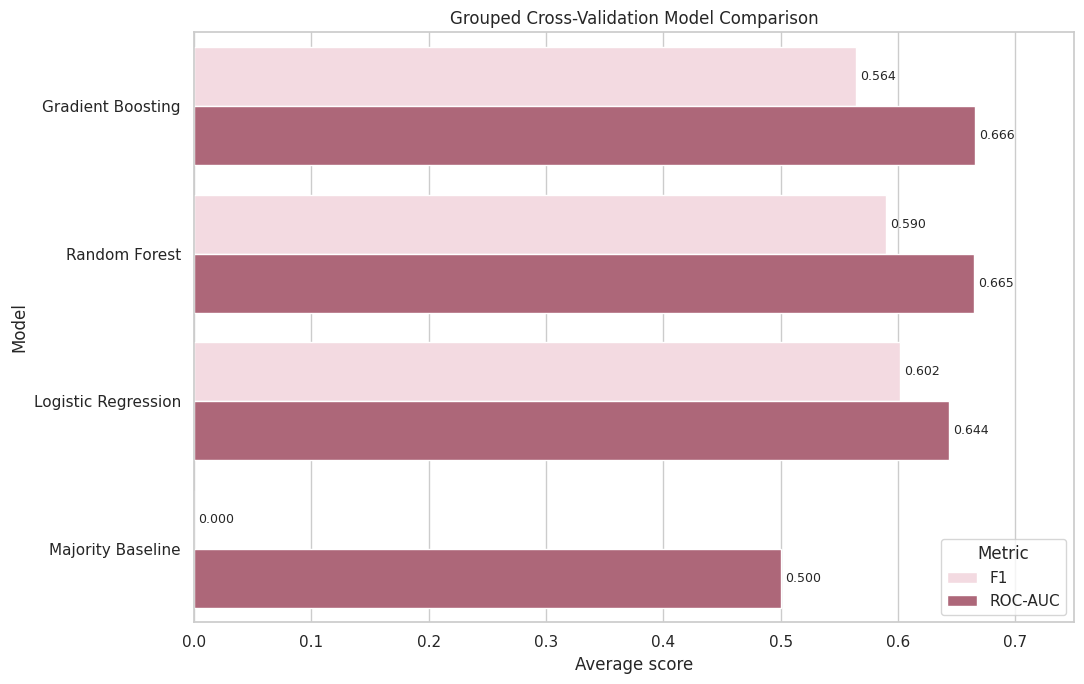

In [54]:
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=cv_chart,
    x="Score",
    y="Model",
    hue="Metric",
    palette={
        "F1": LIGHT_PINK,
        "ROC-AUC": DARK_PINK
    }
)

plt.title(
    "Grouped Cross-Validation Model Comparison"
)

plt.xlabel("Average score")
plt.ylabel("Model")

plt.xlim(0, 0.75)

plt.legend(
    title="Metric",
    loc="lower right"
)

# Add values to the bars

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

- Random Forest and Gradient Boosting had the highest average ROC-AUC scores. This means that they were better at separating the two readmission groups.

- Logistic Regression had the highest recall and F1 score. It found more of the above expected readmission rows and provided the best balance between precision and recall.

- All three classification models performed better than the baseline. However, the scores were moderate. This shows that hospital characteristics and patient experience measures provide useful information, but they cannot fully explain readmission differences.

## 8. Evaluate the Models With the Testing Data

The models will now be trained with all the training data and evaluated one time with the testing data.

The testing hospitals were not used during model training or cross-validation.

### 8.1 Import the Testing Evaluation Tools

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

### 8.2 Train and Test the Models

Each model will use the same training and testing data.

In [57]:
# Store the final results and predictions

test_results = []

trained_models = {}
test_predictions = {}
test_probabilities = {}

for model_name, classifier in models.items():

    print("Training:", model_name)

    # Create a new model pipeline

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                clone(classifier)
            )
        ]
    )

    # Train the model

    model_pipeline.fit(
        X_train,
        y_train
    )

    # Make class predictions

    predictions = model_pipeline.predict(
        X_test
    )

    # Make probability predictions

    probabilities = (
        model_pipeline.predict_proba(
            X_test
        )[:, 1]
    )

    # Save the trained model and predictions

    trained_models[
        model_name
    ] = model_pipeline

    test_predictions[
        model_name
    ] = predictions

    test_probabilities[
        model_name
    ] = probabilities

    # Calculate evaluation metrics

    test_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

print("Testing complete.")

Training: Majority Baseline
Training: Logistic Regression
Training: Random Forest
Training: Gradient Boosting
Testing complete.


### 8.3 Review the Testing Results

In [58]:
# Create the testing-results table

test_results_df = pd.DataFrame(
    test_results
)

test_results_df = test_results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

test_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.624,0.602,0.565,0.583,0.675
1,Gradient Boosting,0.627,0.622,0.507,0.558,0.674
2,Logistic Regression,0.606,0.571,0.615,0.592,0.655
3,Majority Baseline,0.535,0.000,0.000,0.000,0.500


### 8.4 Prepare the Testing Comparison Chart

In [59]:
# Reshape the testing results

test_chart = test_results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "F1",
        "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

test_chart["Metric"] = (
    test_chart["Metric"]
    .replace({
        "ROC_AUC": "ROC-AUC"
    })
)

test_chart

,Model,Metric,Score
0,Random Forest,Accuracy,0.623704
1,Gradient Boosting,Accuracy,0.627310
2,Logistic Regression,Accuracy,0.605678
3,Majority Baseline,Accuracy,0.534926
4,Random Forest,F1,0.582709
5,Gradient Boosting,F1,0.558462
6,Logistic Regression,F1,0.592075
7,Majority Baseline,F1,0.000000
8,Random Forest,ROC-AUC,0.674632
9,Gradient Boosting,ROC-AUC,0.674305


### 8.5 Create the Testing Comparison Chart

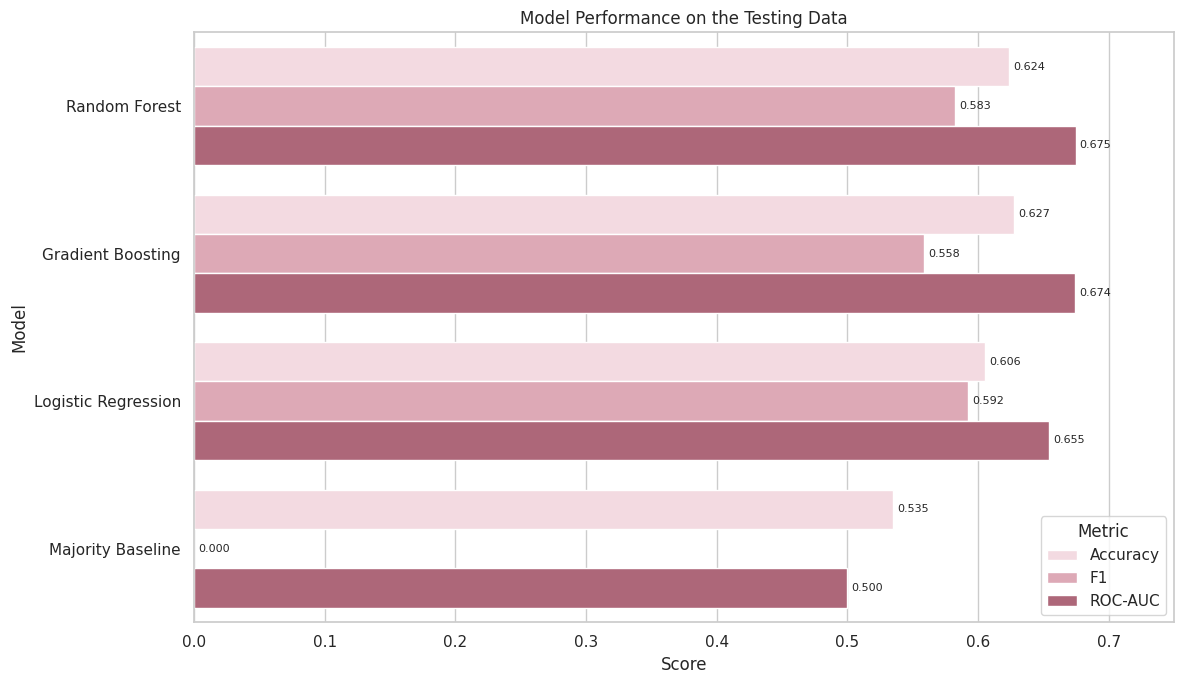

In [60]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=test_chart,
    x="Score",
    y="Model",
    hue="Metric",
    palette={
        "Accuracy": LIGHT_PINK,
        "F1": SOFT_PINK,
        "ROC-AUC": DARK_PINK
    }
)

plt.title(
    "Model Performance on the Testing Data"
)

plt.xlabel("Score")
plt.ylabel("Model")

plt.xlim(0, 0.75)

plt.legend(
    title="Metric",
    loc="lower right"
)

# Add values to the bars

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 8.6 Compare the ROC Curves

The ROC curve shows how well each model separates the two readmission groups. A curve closer to the upper left corner represents better performance.

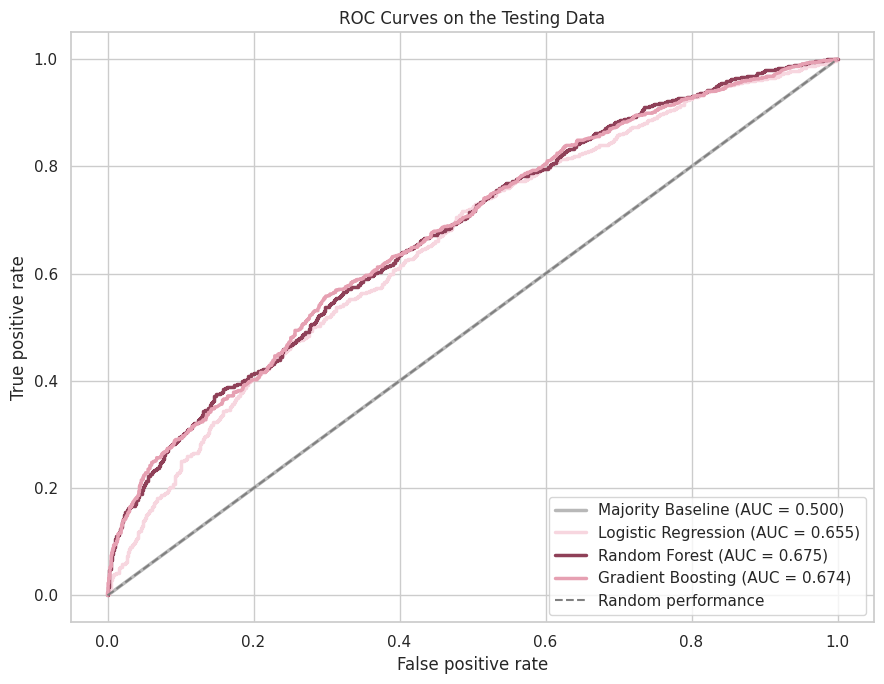

In [61]:
plt.figure(figsize=(9, 7))

roc_colors = {
    "Majority Baseline": "#B8B8B8",
    "Logistic Regression": LIGHT_PINK,
    "Random Forest": DEEP_ROSE,
    "Gradient Boosting": SOFT_PINK
}

for model_name in models:

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_test,
            test_probabilities[
                model_name
            ]
        )
    )

    model_auc = roc_auc_score(
        y_test,
        test_probabilities[
            model_name
        ]
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2.5,
        color=roc_colors[model_name],
        label=(
            f"{model_name} "
            f"(AUC = {model_auc:.3f})"
        )
    )

# Add the random-performance line

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Random performance"
)

plt.title("ROC Curves on the Testing Data")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 8.7 Select the Final Model

Random Forest was selected as the main model because it had one of the highest cross-validation ROC-AUC scores and the highest testing ROC-AUC score.

In [62]:
# Select the final model

final_model_name = "Random Forest"

final_model = trained_models[
    final_model_name
]

final_predictions = test_predictions[
    final_model_name
]

final_probabilities = test_probabilities[
    final_model_name
]

print("Final model:", final_model_name)

Final model: Random Forest


### 8.8 Create the Random Forest Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the final model.

In [64]:
# Calculate the confusion matrix

final_confusion_matrix = confusion_matrix(
    y_test,
    final_predictions
)

final_confusion_matrix

array([[801, 386],
       [449, 583]])

### 8.9 Plot the Confusion Matrix

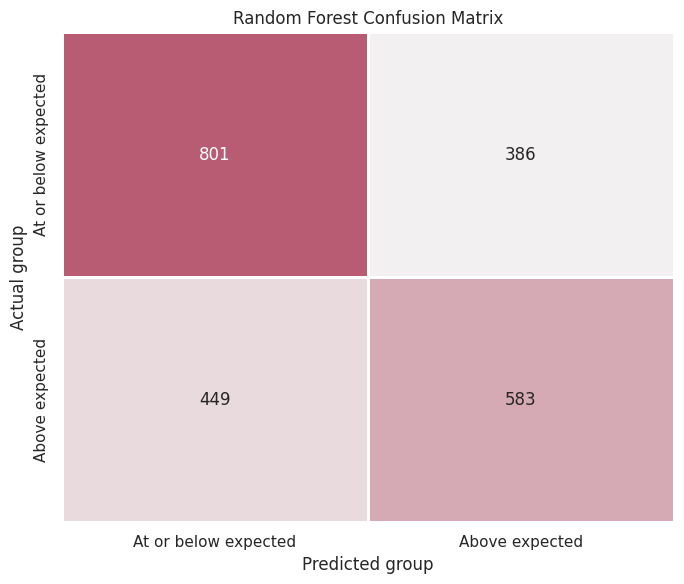

In [65]:
# Create a soft pink color map

confusion_colors = sns.light_palette(
    DARK_PINK,
    as_cmap=True
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap=confusion_colors,
    cbar=False,
    linewidths=1,
    linecolor="white",
    xticklabels=[
        "At or below expected",
        "Above expected"
    ],
    yticklabels=[
        "At or below expected",
        "Above expected"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted group")
plt.ylabel("Actual group")

plt.tight_layout()
plt.show()

- Random Forest had an accuracy of approximately 62.4% and a ROC-AUC of approximately 0.675. It correctly identified 583 above-expected rows and 801 rows that were at or below the expected level.

- The model missed 449 above expected rows and incorrectly classified 386 rows as above expected. Its recall was approximately 56.5%.

- Logistic Regression had a higher recall, so it found more of the above expected rows. Random Forest had better overall separation between the two groups. These models can support exploration, but their performance is not strong enough for clinical decisions.

## 9. Interpret the Final Model

This section uses permutation importance to examine which features were most useful to the Random Forest model.

Permutation importance measures how much the model's ROC-AUC decreases when the values of one feature are randomly mixed. A larger decrease means that the feature was more useful for prediction.

### 9.1 Import the Permutation-Importance Tool

In [66]:
from sklearn.inspection import (
    permutation_importance
)

### 9.2 Calculate Feature Importance

Each feature will be randomly mixed ten times. This cell may take a few minutes.

In [67]:
# Calculate permutation importance

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance complete.")

Permutation importance complete.


### 9.3 Create the Feature Importance Table

In [68]:
# Readable feature names

feature_labels = {
    "number_of_discharges":
        "Number of discharges",

    "condition":
        "Medical condition",

    "ownership_group":
        "Ownership group",

    "emergency_services":
        "Emergency services",

    "promoting_interoperability":
        "EHR interoperability",

    "nurse_communication_pct":
        "Nurse communication",

    "doctor_communication_pct":
        "Doctor communication",

    "staff_responsiveness_pct":
        "Staff responsiveness",

    "discharge_information_pct":
        "Discharge information",

    "definitely_recommend_pct":
        "Definitely recommend",

    "care_transition_score":
        "Care transition"
}

# Create the importance table

importance_df = pd.DataFrame({
    "feature": model_features,
    "importance": (
        permutation_results
        .importances_mean
    ),
    "importance_std": (
        permutation_results
        .importances_std
    )
})

# Add readable names

importance_df["feature_name"] = (
    importance_df["feature"]
    .map(feature_labels)
)

# Sort the values

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance_df[
    [
        "feature_name",
        "importance",
        "importance_std"
    ]
].round(4)

,feature_name,importance,importance_std
0,Number of discharges,0.1275,0.0034
1,Medical condition,0.0236,0.0039
2,Discharge information,0.0220,0.0083
3,Doctor communication,0.0096,0.0025
4,Ownership group,0.0037,0.0028
5,Nurse communication,0.0036,0.0026
6,Staff responsiveness,0.0026,0.0027
7,Definitely recommend,0.0022,0.0027
8,Care transition,0.0021,0.0024
9,EHR interoperability,0.0005,0.0005


### 9.4 Prepare the Feature-Importance Chart

In [69]:
# Sort from lowest to highest for the chart

importance_chart = importance_df.sort_values(
    "importance",
    ascending=True
).copy()

importance_chart[
    [
        "feature_name",
        "importance"
    ]
]

,feature_name,importance
10,Emergency services,-0.001961
9,EHR interoperability,0.000490
8,Care transition,0.002144
7,Definitely recommend,0.002205
6,Staff responsiveness,0.002635
5,Nurse communication,0.003624
4,Ownership group,0.003719
3,Doctor communication,0.009643
2,Discharge information,0.021964
1,Medical condition,0.023555


### 9.5 Create the Feature-Importance Chart

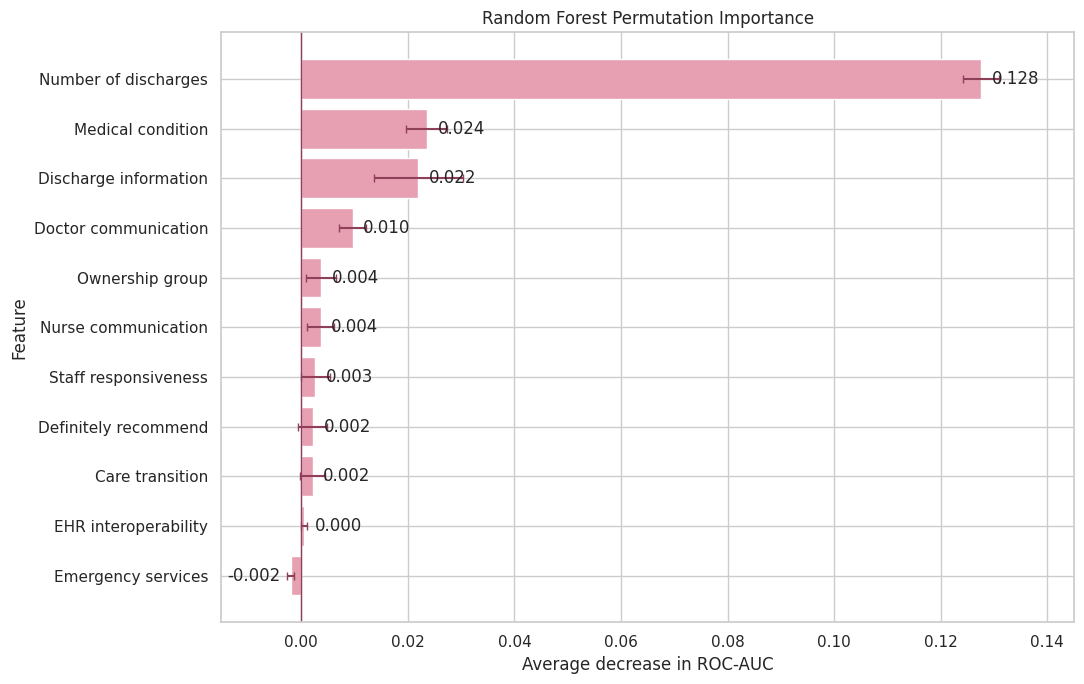

In [70]:
plt.figure(figsize=(11, 7))

bars = plt.barh(
    importance_chart["feature_name"],
    importance_chart["importance"],
    xerr=importance_chart["importance_std"],
    color=SOFT_PINK,
    edgecolor="white",
    ecolor=DEEP_ROSE,
    capsize=3
)

# Add a line at zero

plt.axvline(
    0,
    color=DEEP_ROSE,
    linewidth=1
)

plt.title(
    "Random Forest Permutation Importance"
)

plt.xlabel(
    "Average decrease in ROC-AUC"
)

plt.ylabel("Feature")

# Add importance values

for bar in bars:
    value = bar.get_width()

    if value >= 0:
        label_position = value + 0.002
        horizontal_alignment = "left"
    else:
        label_position = value - 0.002
        horizontal_alignment = "right"

    plt.text(
        label_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        ha=horizontal_alignment,
        va="center"
    )

plt.xlim(-0.015, 0.145)

plt.tight_layout()
plt.show()

- The number of discharges was the most useful feature for the Random Forest model. The medical condition and discharge information score were the next most useful features.

- The other patient-experience and hospital features had smaller importance values. Emergency services had a value close to zero, which means that it did not improve the model's ROC-AUC in this test.

- Feature importance does not show whether a variable increases or decreases readmissions. It only shows how useful the variable was for prediction. It also does not prove that any feature causes readmissions.

## 10. Analyze the Data With SQL

This section creates a SQLite database with three connected tables:

- `readmissions`: Readmission results by hospital and condition.
- `hospitals`: Hospital location and characteristics.
- `patient_experience`: HCAHPS patient-experience measures.

The tables are connected with `facility_id`.

### 10.1 Import SQLite

In [71]:
import sqlite3

### 10.2 Create the Readmissions Table

This table contains one row for each hospital and medical condition.

In [72]:
# Select readmission columns

readmissions_table = model_data[
    [
        "facility_id",
        "condition",
        "number_of_discharges",
        "excess_readmission_ratio",
        "high_readmission"
    ]
].drop_duplicates(
    subset=[
        "facility_id",
        "condition"
    ]
).copy()

print(
    "Readmissions table shape:",
    readmissions_table.shape
)

readmissions_table.head()

Readmissions table shape: (11441, 5)


,facility_id,condition,number_of_discharges,excess_readmission_ratio,high_readmission
0,010001,Hip/knee replacement,NaN,0.9875,0
1,010001,Bypass surgery (CABG),137.0,0.9531,0
2,010001,Heart attack (AMI),273.0,0.9370,0
3,010001,COPD,122.0,0.9823,0
4,010001,Pneumonia,507.0,0.9871,0


### 10.3 Create the Hospitals Table

This table contains one row for each hospital.

In [73]:
# Select hospital columns

hospitals_table = model_data[
    [
        "facility_id",
        "facility_name",
        "state",
        "city",
        "county",
        "zip_code",
        "hospital_type",
        "hospital_ownership",
        "ownership_group",
        "emergency_services",
        "promoting_interoperability"
    ]
].drop_duplicates(
    subset="facility_id"
).copy()

print(
    "Hospitals table shape:",
    hospitals_table.shape
)

hospitals_table.head()

Hospitals table shape: (2670, 11)


,facility_id,facility_name,state,city,county,zip_code,hospital_type,hospital_ownership,ownership_group,emergency_services,promoting_interoperability
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Acute Care Hospitals,Government - Hospital District or Authority,Government,Yes,Yes
6,010005,MARSHALL MEDICAL CENTERS,AL,BOAZ,MARSHALL,35957,Acute Care Hospitals,Government - Hospital District or Authority,Government,Yes,Yes
10,010006,NORTH ALABAMA MEDICAL CENTER,AL,FLORENCE,LAUDERDALE,35630,Acute Care Hospitals,Proprietary,Proprietary,Yes,Yes
16,010007,MIZELL MEMORIAL HOSPITAL,AL,OPP,COVINGTON,36467,Acute Care Hospitals,Voluntary non-profit - Private,Nonprofit,Yes,Yes
19,010011,ST. VINCENT'S EAST,AL,BIRMINGHAM,JEFFERSON,35235,Acute Care Hospitals,Voluntary non-profit - Private,Nonprofit,Yes,Yes


### 10.4 Create the Patient-Experience Table

This table contains one row for each hospital and its patient-experience measures.

In [74]:
# Select patient-experience columns

patient_experience_table = model_data[
    [
        "facility_id",
        "nurse_communication_pct",
        "doctor_communication_pct",
        "staff_responsiveness_pct",
        "discharge_information_pct",
        "definitely_recommend_pct",
        "care_transition_score"
    ]
].drop_duplicates(
    subset="facility_id"
).copy()

print(
    "Patient-experience table shape:",
    patient_experience_table.shape
)

patient_experience_table.head()

Patient-experience table shape: (2670, 7)


,facility_id,nurse_communication_pct,doctor_communication_pct,staff_responsiveness_pct,discharge_information_pct,definitely_recommend_pct,care_transition_score
0,010001,73.0,78.0,59.0,85.0,74.0,82.0
6,010005,76.0,80.0,51.0,86.0,62.0,80.0
10,010006,73.0,75.0,49.0,83.0,56.0,76.0
16,010007,78.0,83.0,67.0,90.0,67.0,81.0
19,010011,78.0,79.0,67.0,86.0,69.0,81.0


### 10.5 Create the SQLite Database

The database will be saved inside the project's data folder in Google Drive.

In [75]:
# Database file location

DATABASE_PATH = (
    DATA_DIR
    / "hospital_readmissions.db"
)

# Connect to the database

connection = sqlite3.connect(
    DATABASE_PATH
)

# Save the DataFrames as SQL tables

readmissions_table.to_sql(
    "readmissions",
    connection,
    if_exists="replace",
    index=False
)

hospitals_table.to_sql(
    "hospitals",
    connection,
    if_exists="replace",
    index=False
)

patient_experience_table.to_sql(
    "patient_experience",
    connection,
    if_exists="replace",
    index=False
)

print("Database created:", DATABASE_PATH)

Database created: /content/drive/MyDrive/us_hospital_readmissions_analysis/data/hospital_readmissions.db


### 10.6 Review the SQL Tables

In [76]:
# List the tables in the database

tables_query = """
SELECT
    name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

pd.read_sql_query(
    tables_query,
    connection
)

,table_name
0,hospitals
1,patient_experience
2,readmissions


### 10.7 Compare readmissions by medical condition

This SQL query calculates the percentage of above-expected readmissions for each condition.

In [77]:
condition_query = """
SELECT
    condition,
    COUNT(*) AS hospital_condition_rows,
    COUNT(DISTINCT facility_id) AS hospitals,
    ROUND(
        100.0 * AVG(high_readmission),
        1
    ) AS high_readmission_pct,
    ROUND(
        AVG(excess_readmission_ratio),
        3
    ) AS average_ratio
FROM readmissions
GROUP BY condition
ORDER BY high_readmission_pct DESC;
"""

condition_sql_results = pd.read_sql_query(
    condition_query,
    connection
)

condition_sql_results

,condition,hospital_condition_rows,hospitals,high_readmission_pct,average_ratio
0,Bypass surgery (CABG),878,878,49.9,1.002
1,Heart attack (AMI),1732,1732,49.7,1.002
2,Heart failure,2543,2543,48.8,1.001
3,Hip/knee replacement,1428,1428,47.9,1.004
4,Pneumonia,2573,2573,47.3,1.002
5,COPD,2287,2287,47.3,1.001


The SQL results showed that bypass surgery and heart attack had the highest percentages of above expected readmissions. However, the differences between the six conditions were small.

### 10.8 Compare Readmissions by Hospital Ownership

This query joins the `readmissions` and `hospitals` tables using `facility_id`.

In [78]:
ownership_query = """
SELECT
    h.ownership_group,
    COUNT(*) AS hospital_condition_rows,
    COUNT(
        DISTINCT h.facility_id
    ) AS hospitals,
    ROUND(
        100.0 * AVG(r.high_readmission),
        1
    ) AS high_readmission_pct
FROM readmissions AS r
INNER JOIN hospitals AS h
    ON r.facility_id = h.facility_id
GROUP BY h.ownership_group
ORDER BY high_readmission_pct DESC;
"""

ownership_sql_results = pd.read_sql_query(
    ownership_query,
    connection
)

ownership_sql_results

,ownership_group,hospital_condition_rows,hospitals,high_readmission_pct
0,Proprietary,2059,509,54.7
1,Government,1383,344,50.3
2,Nonprofit,7913,1769,46.3
3,Physician-owned,75,44,41.3
4,Tribal,11,4,36.4


Proprietary hospitals had the highest percentage of above expected readmissions. Government and nonprofit hospitals had lower percentages.

The physician owned and Tribal groups contained fewer hospitals, so their percentages should be interpreted carefully.

### 10.9 Compare Patient Experience by Readmission Group

This query joins the `readmissions` and `patient_experience` tables. It compares the average patient-experience measures for the two target groups.

In [79]:
experience_query = """
SELECT
    CASE
        WHEN r.high_readmission = 1
            THEN 'Above expected'
        ELSE 'At or below expected'
    END AS readmission_group,

    COUNT(*) AS hospital_condition_rows,

    ROUND(
        AVG(p.nurse_communication_pct),
        1
    ) AS nurse_communication_pct,

    ROUND(
        AVG(p.doctor_communication_pct),
        1
    ) AS doctor_communication_pct,

    ROUND(
        AVG(p.staff_responsiveness_pct),
        1
    ) AS staff_responsiveness_pct,

    ROUND(
        AVG(p.discharge_information_pct),
        1
    ) AS discharge_information_pct,

    ROUND(
        AVG(p.definitely_recommend_pct),
        1
    ) AS definitely_recommend_pct,

    ROUND(
        AVG(p.care_transition_score),
        1
    ) AS care_transition_score

FROM readmissions AS r

INNER JOIN patient_experience AS p
    ON r.facility_id = p.facility_id

GROUP BY r.high_readmission
ORDER BY r.high_readmission;
"""

experience_sql_results = pd.read_sql_query(
    experience_query,
    connection
)

experience_sql_results

,readmission_group,hospital_condition_rows,nurse_communication_pct,doctor_communication_pct,staff_responsiveness_pct,discharge_information_pct,definitely_recommend_pct,care_transition_score
0,At or below expected,5919,76.9,77.3,60.0,85.8,67.8,80.2
1,Above expected,5522,75.7,76.1,58.6,84.6,65.4,79.4


- Hospital condition rows at or below the expected readmission level had slightly higher averages for all six patient-experience measures.

- The largest difference was in the percentage of patients who would definitely recommend the hospital. These differences were small and do not prove causation.

### 10.10 Close the Database Connection

In [80]:
# Save database changes and close the connection

connection.commit()
connection.close()

print("Database connection closed.")

Database connection closed.


## 11. Save the Project Results

This section creates a dashboard ready dataset and saves the model results, feature importance, SQL results, and SQL queries in Google Drive.

The dashboard data can later be used in Tableau Public.

### 11.1 Create the Output Folders

In [81]:
# Create project output folders

OUTPUT_DIR = PROJECT_DIR / "outputs"
SQL_DIR = PROJECT_DIR / "sql"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SQL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output folder:", OUTPUT_DIR)
print("SQL folder:", SQL_DIR)

Output folder: /content/drive/MyDrive/us_hospital_readmissions_analysis/outputs
SQL folder: /content/drive/MyDrive/us_hospital_readmissions_analysis/sql


### 11.2 Create the Dashboard Dataset

The dashboard dataset contains the original hospital information, readable target labels, and Random Forest predictions for the testing rows.

Predictions are only included for the testing hospitals.

In [82]:
# Create a copy for the dashboard

dashboard_data = model_data.copy()

# Add readable target labels

dashboard_data["readmission_group"] = (
    dashboard_data["high_readmission"]
    .map({
        0: "At or below expected",
        1: "Above expected"
    })
)

# Identify training and testing rows

dashboard_data["data_split"] = "Training"

dashboard_data.loc[
    X_test.index,
    "data_split"
] = "Testing"

# Create empty prediction columns

dashboard_data[
    "predicted_probability"
] = np.nan

dashboard_data[
    "predicted_readmission_group"
] = pd.Series(
    pd.NA,
    index=dashboard_data.index,
    dtype="string"
)

dashboard_data[
    "prediction_result"
] = pd.Series(
    pd.NA,
    index=dashboard_data.index,
    dtype="string"
)

### 11.3 Add the Testing Predictions

In [83]:
# Add predicted probabilities

dashboard_data.loc[
    X_test.index,
    "predicted_probability"
] = final_probabilities

# Create readable prediction labels

prediction_labels = pd.Series(
    final_predictions,
    index=X_test.index
).map({
    0: "At or below expected",
    1: "Above expected"
})

dashboard_data.loc[
    X_test.index,
    "predicted_readmission_group"
] = prediction_labels

# Identify correct and incorrect predictions

prediction_results = pd.Series(
    np.where(
        final_predictions
        == y_test.to_numpy(),
        "Correct",
        "Incorrect"
    ),
    index=X_test.index
)

dashboard_data.loc[
    X_test.index,
    "prediction_result"
] = prediction_results

# Round the probabilities

dashboard_data[
    "predicted_probability"
] = dashboard_data[
    "predicted_probability"
].round(4)

dashboard_data.head()

,facility_id,facility_name,state,city,county,zip_code,condition,measure_name,number_of_discharges,discharge_count_missing,...,high_readmission,hrrp_start_date,hrrp_end_date,hcahps_start_date,hcahps_end_date,readmission_group,data_split,predicted_probability,predicted_readmission_group,prediction_result
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Hip/knee replacement,READM-30-HIP-KNEE-HRRP,NaN,1,...,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023,At or below expected,Training,NaN,<NA>,<NA>
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Bypass surgery (CABG),READM-30-CABG-HRRP,137.0,0,...,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023,At or below expected,Training,NaN,<NA>,<NA>
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Heart attack (AMI),READM-30-AMI-HRRP,273.0,0,...,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023,At or below expected,Training,NaN,<NA>,<NA>
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,COPD,READM-30-COPD-HRRP,122.0,0,...,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023,At or below expected,Training,NaN,<NA>,<NA>
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,DOTHAN,HOUSTON,36301,Pneumonia,READM-30-PN-HRRP,507.0,0,...,0,07/01/2021,06/30/2024,10/01/2022,09/30/2023,At or below expected,Training,NaN,<NA>,<NA>


### 11.4 Check the Dashboard Prediction Columns

In [84]:
# Review testing rows

dashboard_data.loc[
    dashboard_data["data_split"] == "Testing",
    [
        "facility_name",
        "condition",
        "readmission_group",
        "predicted_probability",
        "predicted_readmission_group",
        "prediction_result"
    ]
].head()

,facility_name,condition,readmission_group,predicted_probability,predicted_readmission_group,prediction_result
136,NORTHWEST MEDICAL CENTER,Pneumonia,At or below expected,0.2393,At or below expected,Correct
137,NORTHWEST MEDICAL CENTER,Heart failure,Above expected,0.2899,At or below expected,Incorrect
138,NORTHWEST MEDICAL CENTER,COPD,At or below expected,0.3767,At or below expected,Correct
139,USA HEALTH UNIVERSITY HOSPITAL,Heart failure,Above expected,0.8527,Above expected,Correct
140,USA HEALTH UNIVERSITY HOSPITAL,Heart attack (AMI),At or below expected,0.4388,At or below expected,Correct


### 11.5 Save the Tableau Dashboard Data

In [85]:
# Dashboard file location

DASHBOARD_PATH = (
    DATA_DIR
    / "tableau_dashboard_data.csv"
)

# Save the dashboard data

dashboard_data.to_csv(
    DASHBOARD_PATH,
    index=False
)

print(
    "Dashboard data saved:",
    DASHBOARD_PATH
)

print(
    "Dashboard data shape:",
    dashboard_data.shape
)

Dashboard data saved: /content/drive/MyDrive/us_hospital_readmissions_analysis/data/tableau_dashboard_data.csv
Dashboard data shape: (11441, 34)


### 11.6 Save the Model Results

In [86]:
# Save cross-validation results

cv_results_df.to_csv(
    OUTPUT_DIR
    / "cross_validation_results.csv",
    index=False
)

# Save testing results

test_results_df.to_csv(
    OUTPUT_DIR
    / "testing_results.csv",
    index=False
)

# Save feature importance

importance_df[
    [
        "feature",
        "feature_name",
        "importance",
        "importance_std"
    ]
].to_csv(
    OUTPUT_DIR
    / "feature_importance.csv",
    index=False
)

print("Model results saved.")

Model results saved.


### 11.7 Save the SQL Query Results

In [87]:
# Save the SQL result tables

condition_sql_results.to_csv(
    OUTPUT_DIR
    / "sql_results_by_condition.csv",
    index=False
)

ownership_sql_results.to_csv(
    OUTPUT_DIR
    / "sql_results_by_ownership.csv",
    index=False
)

experience_sql_results.to_csv(
    OUTPUT_DIR
    / "sql_results_patient_experience.csv",
    index=False
)

print("SQL results saved.")

SQL results saved.


### 11.8 Save the SQL Queries

In [88]:
# Combine the SQL queries

all_sql_queries = f"""
-- Query 1: Readmissions by medical condition

{condition_query}


-- Query 2: Readmissions by hospital ownership

{ownership_query}


-- Query 3: Patient experience by readmission group

{experience_query}
"""

# Save as a SQL file

SQL_FILE_PATH = (
    SQL_DIR
    / "hospital_readmission_analysis.sql"
)

SQL_FILE_PATH.write_text(
    all_sql_queries,
    encoding="utf-8"
)

print(
    "SQL queries saved:",
    SQL_FILE_PATH
)

SQL queries saved: /content/drive/MyDrive/us_hospital_readmissions_analysis/sql/hospital_readmission_analysis.sql


### 11.9 Review the Saved Project Files

In [89]:
print("Project files:\n")

for file in sorted(
    PROJECT_DIR.rglob("*")
):
    if file.is_file():

        file_size = (
            file.stat().st_size
            / (1024 ** 2)
        )

        print(
            "-",
            file.relative_to(
                PROJECT_DIR
            ),
            f"({file_size:.2f} MB)"
        )

Project files:

- data/hospital_readmissions.db (0.87 MB)
- data/model_data.csv (2.88 MB)
- data/tableau_dashboard_data.csv (3.28 MB)
- outputs/cross_validation_results.csv (0.00 MB)
- outputs/feature_importance.csv (0.00 MB)
- outputs/sql_results_by_condition.csv (0.00 MB)
- outputs/sql_results_by_ownership.csv (0.00 MB)
- outputs/sql_results_patient_experience.csv (0.00 MB)
- outputs/testing_results.csv (0.00 MB)
- sql/hospital_readmission_analysis.sql (0.00 MB)


- The project results were saved in Google Drive. The dashboard dataset contains 11,441 hospital condition rows and can be connected to Tableau Public.

- The actual readmission group is available for every row. Random Forest predictions are included only for the testing hospitals. This helps keep the model evaluation separate from the training data.

## 12. Conclusions and Limitations

This section summarizes the main results and explains the limits of the analysis.

### 12.1 Main Findings

- Hospitals at or below the expected readmission level had slightly better average patient experience scores. The largest difference was in the percentage of patients who would definitely recommend the hospital.

- Proprietary hospitals had the highest percentage of above-expected readmission rows in this dataset. However, hospital ownership groups were different in size, and these results do not explain why the differences occurred.

- The number of discharges was the most useful feature for the Random Forest model. Medical condition and discharge information were the next most useful features.

### 12.2 Model Results

- Random Forest had the highest testing ROC-AUC at approximately 0.675. Its accuracy was approximately 62.4%, and its F1 score was approximately 0.583.

- Logistic Regression had the highest recall at approximately 61.5%. This means that it found more of the hospital-condition rows with above expected readmissions.

- The models performed better than the baseline, but their performance was moderate. Hospital characteristics and patient experience measures provided useful information, but they did not fully explain the differences in readmissions.

### 12.3 Answer to the Research Question

- Hospital characteristics and patient experience were related to above expected 30 day readmissions, but most relationships were small.

- Hospitals with better patient experience scores generally had slightly lower percentages of above expected readmissions. Discharge volume, medical condition, ownership, and discharge information also provided useful information for prediction.

- These results show associations at the hospital level. They do not prove that any hospital characteristic or patient experience measure directly causes or prevents readmissions.

### 12.4 Project Limitations

- The data contains hospital-level estimates and not individual patient records.
- The readmission and patient experience periods overlap, but they are not exactly the same.
- The number of discharges was missing in about 30% of the rows.
- Patient experience results are based on survey responses, and response rates can be different across hospitals.
- The dataset does not include every factor that may affect readmissions, such as staffing, follow up care, access to healthcare, or local economic conditions.
- The models were evaluated with one hospital based testing group. Results may be different with another time period.
- The results should not be used alone to make clinical or hospital management decisions.

### 12.5 Future Work

- Future analysis could include hospital staffing, local socioeconomic conditions, healthcare access, and other quality measures.

- The project could also compare multiple years to examine whether hospital readmission patterns change over time. Additional model testing and parameter tuning may improve performance.

- An interactive Tableau dashboard will be created to explore readmissions by state, medical condition, hospital ownership, patient experience, and model results.

### 12.6 Final Statement

- This project combined CMS hospital data, SQL analysis, classification models, and patient experience measures to study above expected 30 day readmissions.

- The results showed that readmissions are a complex hospital outcome. The available features helped identify some patterns, but no single measure could fully explain the differences between hospitals.

## 13. Data Sources and Tools

### Data Sources

The data comes from the Centers for Medicare & Medicaid Services (CMS).

- [Hospital Readmissions Reduction Program](https://data.cms.gov/provider-data/dataset/9n3s-kdb3)
- [Hospital General Information](https://data.cms.gov/provider-data/dataset/xubh-q36u)
- [Patient Survey (HCAHPS) - Hospital](https://data.cms.gov/provider-data/dataset/dgck-syfz)
- [CMS Hospital Data Archives](https://data.cms.gov/provider-data/archived-data/hospitals)

### Measurement Periods

- Hospital readmissions: July 2021 to June 2024
- Patient experience: October 2022 to September 2023
- Hospital information snapshot: July 2024

The periods overlap, but they are not exactly the same. The analysis describes associations and does not prove causation.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SQLite and SQL
- Google Colab
- Tableau Public
- GitHub